# Tune Hyperparameters

In [1]:
import random
import typing as t

import keras_tuner as kt
import numpy as np
import numpy.typing as npt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.subplots as ps
import tensorflow as tf

pio.renderers.default = "svg"

__version__ = "0.2.0"

In [2]:
# Utilities
LabeledData = t.Tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]


def load_data(
    filename: str, test_size: float = 0.2
) -> t.Tuple[LabeledData, LabeledData]:
    def _split_dataset(dataset) -> LabeledData:
        label = np.array([list(df.label)[0] for _, df in dataset])
        data = np.array([list(df.y) for _, df in dataset])
        return label, data

    df = pd.read_csv(filename).assign(label=lambda df: list(zip(df.t0, df.y0)))
    dataset = list(df.groupby("id"))
    random.shuffle(dataset)
    n = int(test_size * len(dataset))
    train_dataset = dataset[n:]
    test_dataset = dataset[:n]
    return _split_dataset(train_dataset), _split_dataset(test_dataset)


def plot_history(history: tf.keras.callbacks.History) -> go.Figure:
    hist = pd.DataFrame(history.history)
    fig = (
        ps.make_subplots(rows=1, cols=2)
        .add_scatter(
            x=history.epoch, y=hist["mse"], line=dict(), name="mse", row=1, col=1
        )
        .add_scatter(
            x=history.epoch,
            y=hist["val_mse"],
            line=dict(),
            name="val_mse",
            row=1,
            col=1,
        )
        .add_scatter(
            x=history.epoch, y=hist["mae"], line=dict(), name="mae", row=1, col=2
        )
        .add_scatter(
            x=history.epoch,
            y=hist["val_mae"],
            line=dict(),
            name="val_mae",
            row=1,
            col=2,
        )
        .update_xaxes(title="Epoch")
        .update_yaxes(title="Mean Squared Error", type="log", row=1, col=1)
        .update_yaxes(title="Mean Absolute Error", type="log", row=1, col=2)
    )
    return fig


def plot_predictions(
    model: tf.keras.Model, data: npt.NDArray[np.float64], label: npt.NDArray[np.float64]
) -> go.Figure:
    predictions = model.predict(data, verbose=0)
    fig = (
        ps.make_subplots(rows=1, cols=2)
        .add_scatter(x=label[:, 0], y=predictions[:, 0], mode="markers", row=1, col=1)
        .update_xaxes(title="True t0", range=(0, 0.3), row=1, col=1)
        .update_yaxes(title="Predicted t0", range=(0, 0.3), row=1, col=1)
        .add_scatter(x=label[:, 1], y=predictions[:, 1], mode="markers", row=1, col=2)
        .update_xaxes(title="True y0", range=(0, 1.0), row=1, col=2)
        .update_yaxes(title="Predicted y0", range=(0, 1.0), row=1, col=2)
        .add_scatter(x=[0, 1], y=[0, 1], line=dict(color="black"), row="all", col="all")
        .update_layout(showlegend=False)
    )
    return fig


def save_history_as_csv(history: tf.keras.callbacks.History, filename: str) -> None:
    pd.DataFrame(history.history).assign(epoch=history.epoch).to_csv(
        filename,
        index=False,
        compression="gzip" if str(filename).endswith(".gz") else None,
    )

## Dataset
Load a dataset.

In [3]:
repo = "https://github.com/wasedatakeuchilab/DL-SCDC"

random.seed(0)
dataset_name = "dataset"
dataset_version = "0.0.0"
test_size = 0.2
(train_label, train_data), (test_label, test_data) = load_data(
    f"{repo}/raw/{dataset_name}/v{dataset_version}/datasets/{dataset_name}.csv.gz",
    test_size,
)

## Search Space
Determine a search space.

Use Hyperband algorithm for searching.

In [4]:
def build_model(hp: kt.HyperParameters) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            tf.keras.Input(len(train_data[0])),
            tf.keras.layers.Dense(
                units=hp.Fixed(
                    "units_1",
                    212
                ),
                activation=hp.Fixed(
                    "activation_1",
                    "tanh"
                )
            ),
            tf.keras.layers.Dropout(
                rate=hp.Float(
                    "dropout_rate_1",
                    min_value=0.0,
                    max_value=1e-4,
                    step=1e-5
                )
            ),
            tf.keras.layers.Dense(
                units=hp.Fixed(
                    "units_2",
                   186
                ),
                activation=hp.Fixed(
                    "activation_2",
                    "relu"
                )
            ),
            tf.keras.layers.Dropout(
                rate=hp.Float(
                    "dropout_rate_2",
                    min_value=0.0,
                    max_value=1e-4,
                    step=1e-5
                )
            ),
            tf.keras.layers.Dense(
                units=hp.Fixed(
                    "units_3",
                   46
                ),
                activation=hp.Fixed(
                    "activation_3",
                    "tanh"
                )
            ),
            tf.keras.layers.Dropout(
                rate=hp.Float(
                    "dropout_rate_3",
                    min_value=0.0,
                    max_value=1e-4,
                    step=1e-5
                )
            ),
            tf.keras.layers.Dense(units=2, activation="sigmoid"),
        ]
    )
    model.compile(
        loss="mse",
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        metrics=["mse", "mae"],
    )
    return model


tuner = kt.Hyperband(
    build_model,
    objective="val_loss",
    max_epochs=500,
    factor=3,
    directory="tuning",
    project_name=f"v{__version__}",
)
tuner.search_space_summary()

INFO:tensorflow:Reloading Oracle from existing project tuning/v0.2.0/oracle.json
INFO:tensorflow:Reloading Tuner from tuning/v0.2.0/tuner0.json
Search space summary
Default search space size: 9
units_1 (Fixed)
{'conditions': [], 'value': 212}
activation_1 (Fixed)
{'conditions': [], 'value': 'tanh'}
dropout_rate_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.0001, 'step': 1e-05, 'sampling': None}
units_2 (Fixed)
{'conditions': [], 'value': 186}
activation_2 (Fixed)
{'conditions': [], 'value': 'relu'}
dropout_rate_2 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.0001, 'step': 1e-05, 'sampling': None}
units_3 (Fixed)
{'conditions': [], 'value': 46}
activation_3 (Fixed)
{'conditions': [], 'value': 'tanh'}
dropout_rate_3 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.0001, 'step': 1e-05, 'sampling': None}


## Search
Search better hyperparameters.

In [5]:
def schedule_learning_rate(epoch: int) -> float:
    if epoch <= 50:
        return 1e-4
    else:
        return 1e-5


tuner.search(
    train_data,
    train_label,
    epochs=200,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20),
        tf.keras.callbacks.LearningRateScheduler(schedule_learning_rate),
    ],
    verbose=0,
)

INFO:tensorflow:Oracle triggered exit


## Best model
Get the best hyperparameters.

Build a new model with it

In [6]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
for name, val in best_hp.values.items():
    print(f"{name:20s}: {val}")
model = tuner.hypermodel.build(best_hp)
model.summary()

units_1             : 212
activation_1        : tanh
dropout_rate_1      : 4e-05
units_2             : 186
activation_2        : relu
dropout_rate_2      : 7.000000000000001e-05
units_3             : 46
activation_3        : tanh
dropout_rate_3      : 5e-05
tuner/epochs        : 500
tuner/initial_epoch : 0
tuner/bracket       : 0
tuner/round         : 0
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 212)               101972    
                                                                 
 dropout_3 (Dropout)         (None, 212)               0         
                                                                 
 dense_5 (Dense)             (None, 186)               39618     
                                                                 
 dropout_4 (Dropout)         (None, 186)               0         
                            

Retrain the model.

In [7]:
history = model.fit(
    train_data,
    train_label,
    epochs=best_hp.get("tuner/epochs"),
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, verbose=1),
        tf.keras.callbacks.LearningRateScheduler(schedule_learning_rate),
    ],
    verbose=0,
)

Epoch 374: early stopping


## Evaluate

In [8]:
loss, mse, mae = model.evaluate(test_data, test_label)

63/63 [==============================] - 1s 9ms/step - loss: 8.9212e-06 - mse: 8.9212e-06 - mae: 0.0018


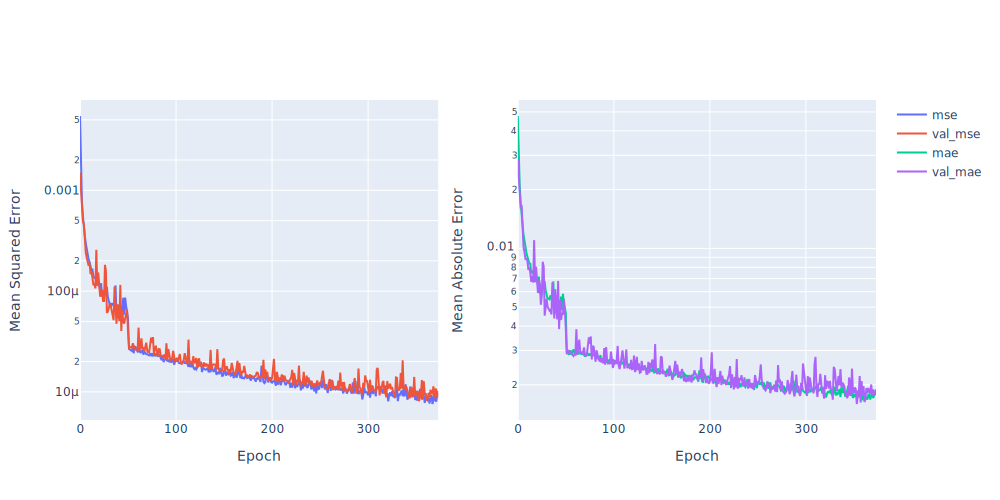

In [9]:
plot_history(history).show(width=1000)
save_history_as_csv(history, f"histories/tuning.csv.gz")

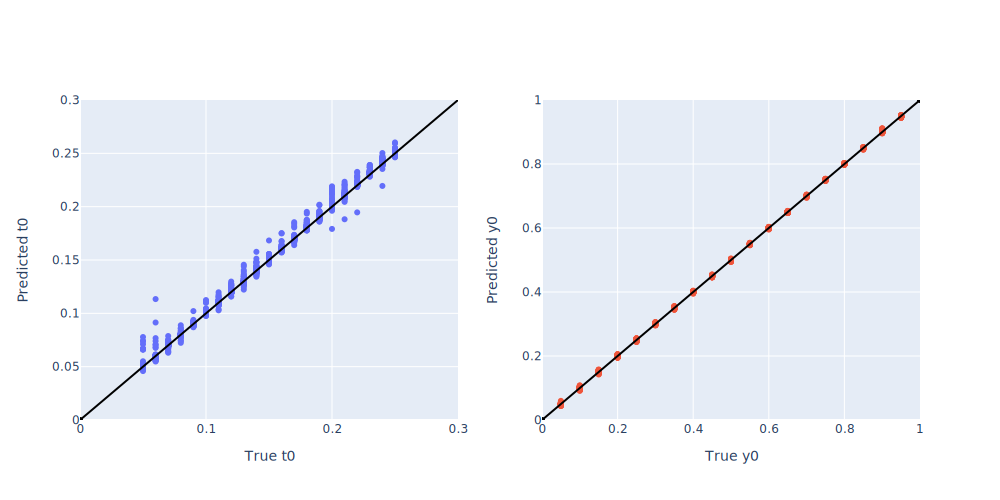

In [10]:
plot_predictions(model, test_data, test_label).show(width=1000)

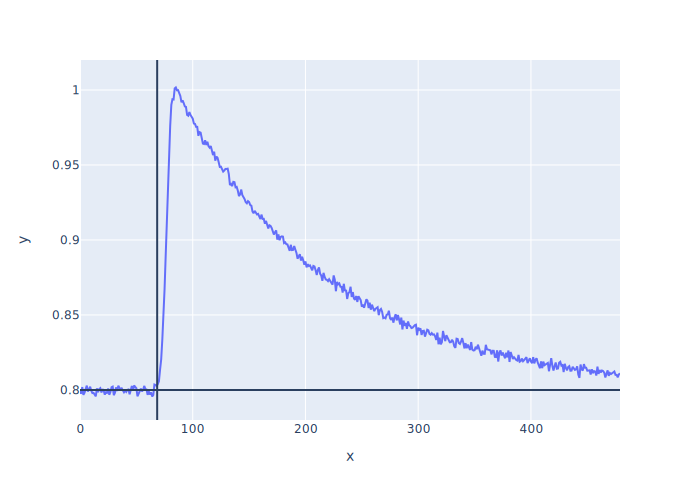

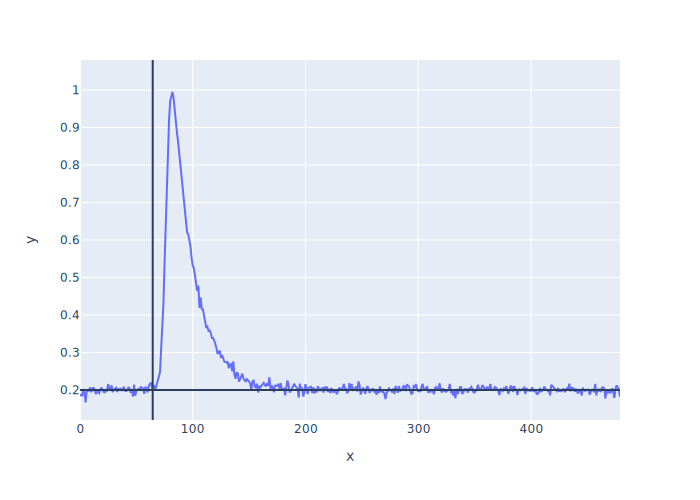

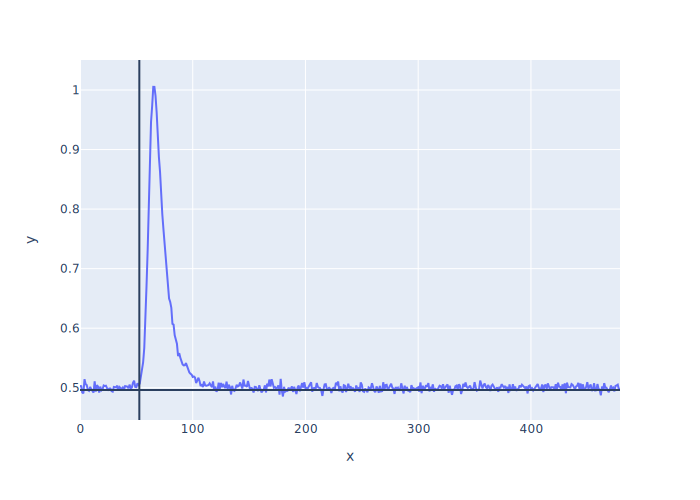

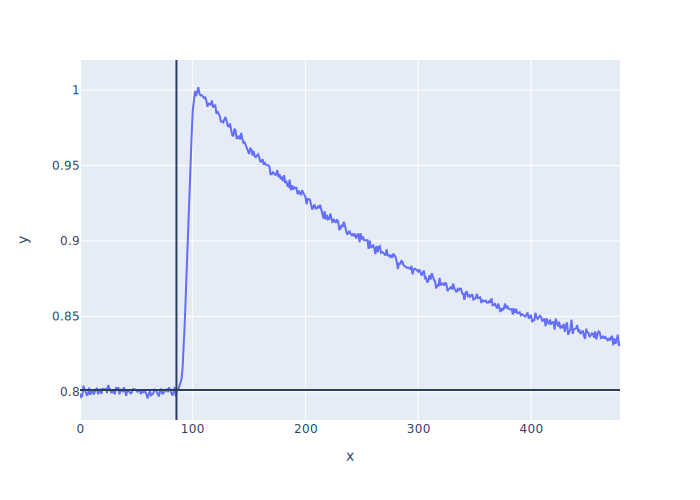

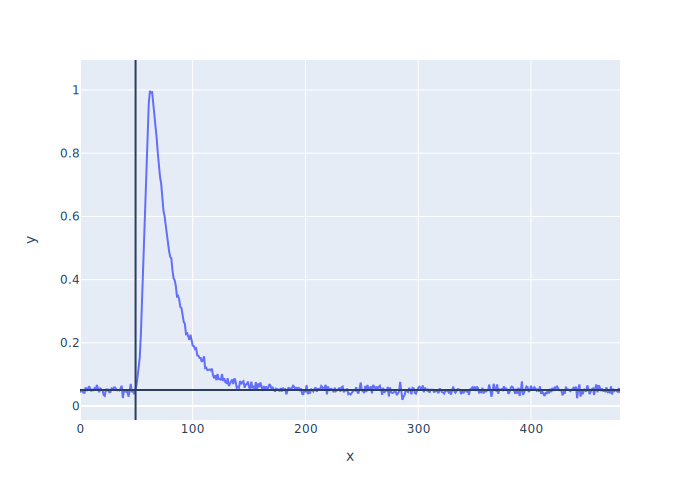

In [11]:
for data in random.sample(list(test_data), 5):
    prediction, *_ = model.predict(np.expand_dims(data, 0), verbose=0)
    d = (1.0 - prediction[1]) * 0.1
    px.line(y=data, range_y=(prediction[1] - d, 1 + d)).add_vline(
        prediction[0] * len(data)
    ).add_hline(prediction[1]).show()

## Save
Save the model.

In [12]:
filename = f"tuning"
model.save(f"models/{filename}")
!tar czf models/"$filename".tar.gz -C models $filename

INFO:tensorflow:Assets written to: models/tuning/assets


Copyright (c) 2022 Shuhei Nitta